# 09: Do account history features beat the shipped model?

Notebooks 03-08 never use `nameOrig`/`nameDest` as anything but identifiers to
drop (`C.ID_COLUMNS`) even though 63.28% of test rows involve a destination
account already seen in training (`02_account_overlap.json`). This notebook
asks whether turning that history into features moves the needle past the
shipped model's held-out NER of **0.1314** (XGBoost, `no_origin_balance` rung,
`results/04_cost_sensitive.csv`), which is the best NER of every config tried
at that rung.

Ten new columns, all prefixed `vel_` (`src/momo_fraud/velocity.py`): prior
transaction counts (all-time and trailing 24h), unique-recipient/unique-sender
counts (fan-out/fan-in the second is a mule-account signal), steps since
last activity, and a first-time-account flag, computed separately for the
origin and destination side of each transaction.

**Why this can't leak.** Every one of those ten columns is a function of
transactions *strictly before* the row's own `step` see the module
docstring for the full argument. Because of that, the features are computed
**once, on the full ordered table, before either split below is constructed** 
nothing about train/val/test membership ever enters the computation. That
is also why this notebook checks the result under **both** splits already in
`splits.py`: the primary stratified split, and the temporal split (train on
the past, test on the future), which is the harder, more honest test of a
history feature and the one closest to how a live system would actually see
this data.

Cost-sensitivity is a *settled* question here (notebooks 04/06): none of the
twelve training-time comparisons beat plain thresholding for the two strongest
learners. So this notebook only touches the unweighted variant (configs A/B/C) 
the question is purely "do these features help", not "does weighting help
these features".

In [1]:
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import constants as C
from momo_fraud import data as D
from momo_fraud import evaluate as E
from momo_fraud import experiment as X
from momo_fraud import risk as RK
from momo_fraud import splits as S
from momo_fraud import viz
from momo_fraud.features import FeatureBuilder, columns_for
from momo_fraud.velocity import VELOCITY_FEATURES, build_velocity_features

viz.apply_house_style()

# Resolves to the validation-selected decision when present, falling back to
# the original test-selected one. Both name the same rung; the preference
# order exists so a future re-derivation cannot silently fall back.
decision = X.load_experimental_rung()
RUNG = decision["experimental_rung"]
SEED = C.RANDOM_SEED
R = C.R_DEFAULT

baseline_row = (pd.read_csv(PROJECT_ROOT / "results" / "04_cost_sensitive.csv")
                .query("learner == 'xgboost' and split == 'test' and feature_set == @RUNG "
                       "and config in ['B', 'C']")
                .iloc[0])
BASELINE_NER = float(baseline_row["ner"])
print(f"rung: {RUNG}")
print(f"shipped-model baseline to beat: XGBoost NER = {BASELINE_NER:.4f} (config {baseline_row['config']})")

rung: no_origin_balance
shipped-model baseline to beat: XGBoost NER = 0.1314 (config B)


## Build velocity features once

Before either split is constructed the cell ordering here *is* the leakage
argument made visible.

In [2]:
df = D.load()
y = df[C.TARGET].to_numpy()

start = time.perf_counter()
vel_all = build_velocity_features(df)
print(f"velocity features built in {time.perf_counter() - start:.0f}s")
vel_all.describe().T.round(3)

velocity features built in 116s


,count,mean,std,min,25%,50%,75%,max
vel_orig_prior_count,6362620.0,0.003,0.134,0.0,0.0,0.0,0.0,57.0
vel_orig_prior_count_24h,6362620.0,0.000,0.022,0.0,0.0,0.0,0.0,16.0
vel_orig_unique_recipients,6362620.0,0.001,0.038,0.0,0.0,0.0,0.0,2.0
vel_orig_steps_since_last,6362620.0,-0.760,7.765,-1.0,-1.0,-1.0,-1.0,704.0
vel_orig_is_first_seen,6362620.0,0.998,0.040,0.0,1.0,1.0,1.0,1.0
vel_dest_prior_count,6362620.0,5.028,7.820,0.0,0.0,1.0,7.0,112.0
vel_dest_prior_count_24h,6362620.0,1.062,2.613,0.0,0.0,0.0,1.0,91.0
vel_dest_unique_senders,6362620.0,5.027,7.819,0.0,0.0,1.0,7.0,112.0
vel_dest_steps_since_last,6362620.0,17.441,40.700,-1.0,-1.0,1.0,20.0,699.0
vel_dest_is_first_seen,6362620.0,0.435,0.496,0.0,0.0,0.0,1.0,1.0


In [3]:
# Sparsity check flagged in the design: PaySim customer origin accounts are
# mostly one-shot, so vel_orig_* should be sparse. vel_dest_* (merchant-like
# accounts, reused heavily) should carry most of the signal.
print(f"vel_orig_is_first_seen mean: {vel_all['vel_orig_is_first_seen'].mean():.4f}")
print(f"vel_dest_is_first_seen mean: {vel_all['vel_dest_is_first_seen'].mean():.4f}")

vel_orig_is_first_seen mean: 0.9984
vel_dest_is_first_seen mean: 0.4352


## Grid A stratified split

The "without velocity" arm at this rung is already cached from notebooks
03/04 (`config B`/`C`, `feature_set == RUNG`), so only the velocity-augmented
arm needs a fresh fit here.

In [4]:
split_strat = S.stratified_split(y)
print("stratified:", split_strat.sizes(), split_strat.prevalence(y))

builder = FeatureBuilder().fit(df.iloc[split_strat.train])
X_all = builder.transform(df)
cols_base = columns_for(RUNG, list(X_all.columns))

X_with_vel = pd.concat([X_all, vel_all], axis=1)
cols_vel = cols_base + VELOCITY_FEATURES

parts_strat_vel = {k: X_with_vel.iloc[getattr(split_strat, k)][cols_vel]
                   for k in ("train", "val", "test")}
labels_strat = {k: y[getattr(split_strat, k)] for k in ("train", "val", "test")}
print(f"{len(cols_vel)} features with velocity ({len(cols_base)} base + {len(VELOCITY_FEATURES)} velocity)")

stratified: {'train': 4453834, 'val': 954392, 'test': 954394} {'train': 0.001290797995614565, 'val': 0.0012908741900602688, 'test': 0.0012908714849422776}


24 features with velocity (14 base + 10 velocity)


In [5]:
start = time.perf_counter()
strat_vel_results = X.run_grid(
    parts_strat_vel["train"], labels_strat["train"],
    parts_strat_vel["val"], labels_strat["val"],
    parts_strat_vel["test"], labels_strat["test"],
    variants=["unweighted"], seeds=[SEED], r=R,
    feature_set=f"{RUNG}_velocity",
)
print(f"stratified + velocity: {time.perf_counter() - start:.0f}s")
strat_vel_results.query("split == 'test'")[["learner", "config", "pr_auc", "ner", "recall", "precision"]].round(4)

[1/4] logistic_regression / unweighted / seed 42 …

   12.6s  test PR-AUC 0.5002


[2/4] decision_tree / unweighted / seed 42 …

   95.1s  test PR-AUC 0.7298


[3/4] random_forest / unweighted / seed 42 …

  180.2s  test PR-AUC 0.7844


[4/4] xgboost / unweighted / seed 42 …

  180.5s  test PR-AUC 0.8107


stratified + velocity: 538s


,learner,config,pr_auc,ner,recall,precision
1,logistic_regression,A,0.5002,0.6721,0.3279,0.9058
3,logistic_regression,B,0.5002,0.2444,0.8352,0.0134
5,logistic_regression,C,0.5002,0.2444,0.8352,0.0134
7,decision_tree,A,0.7298,0.3482,0.6518,0.9745
9,decision_tree,B,0.7298,0.1527,0.8701,0.0470
11,decision_tree,C,0.7298,0.1527,0.8701,0.0470
13,random_forest,A,0.7844,0.3377,0.6623,0.9808
15,random_forest,B,0.7844,0.1324,0.8977,0.0371
17,random_forest,C,0.7844,0.1324,0.8977,0.0371
19,xgboost,A,0.8107,0.2573,0.7427,0.9724


## Grid B temporal split (the robustness check)

Train on the past, test on the future (`splits.temporal_split`). No baseline
exists for this split anywhere in the study, so both arms with and without
velocity are fitted fresh here, at the same rung, for a fair comparison.

In [6]:
# Boundaries are derived from the empirical cumulative row count and the
# realised proportions are asserted inside temporal_split -- the previous
# constants (520/632) assumed a uniform step distribution and realised
# 95.6/3.0/1.4 on the real file, with nothing to catch it.
split_temp = S.temporal_split(df["step"])

# Hitting the row proportions does not equalise the class prior: PaySim's
# fraud prevalence is non-stationary in simulated time. This is recorded
# rather than printed, because a temporal NER is not interpretable without
# it -- NER scores "flag nothing" at 1.0 for any R, but "flag everything"
# reaches 1.0, and Youden coincides with the NER-optimal threshold, only
# where R equals the evaluated partition's class ratio.
temporal_sizes = split_temp.sizes()
temporal_prevalence = split_temp.prevalence(y)
temporal_ratios = split_temp.class_ratio(y)

E.save_results([
    {"partition": part, "n_rows": temporal_sizes[part],
     "share": temporal_sizes[part] / len(df),
     "n_fraud": int(y[getattr(split_temp, part)].sum()),
     "prevalence": temporal_prevalence[part],
     "class_ratio": temporal_ratios[part]}
    for part in ("train", "val", "test")
], "09_temporal_prevalence")

print("temporal:", temporal_sizes)
for part in ("train", "val", "test"):
    print(f"  {part:6s} prevalence {temporal_prevalence[part]:.5%}  "
          f"N_neg/N_pos {temporal_ratios[part]:8.1f}")
print(f"\nR_DEFAULT = {R:.1f}; temporal test class ratio = "
      f"{temporal_ratios['test']:.1f} -- NER at R_DEFAULT is comparable with\n"
      "the stratified arm but is NOT anchored on this partition. "
      "scripts/repairs/repair_01_temporal_split.py\nreports all three cost "
      "ratios; see results/09_temporal_repaired.csv.")

builder_temp = FeatureBuilder().fit(df.iloc[split_temp.train])
X_all_temp = builder_temp.transform(df)
cols_base_temp = columns_for(RUNG, list(X_all_temp.columns))
X_with_vel_temp = pd.concat([X_all_temp, vel_all], axis=1)
cols_vel_temp = cols_base_temp + VELOCITY_FEATURES

parts_temp_novel = {k: X_all_temp.iloc[getattr(split_temp, k)][cols_base_temp]
                    for k in ("train", "val", "test")}
parts_temp_vel = {k: X_with_vel_temp.iloc[getattr(split_temp, k)][cols_vel_temp]
                  for k in ("train", "val", "test")}
labels_temp = {k: y[getattr(split_temp, k)] for k in ("train", "val", "test")}

temporal: {'train': 6082007, 'val': 191155, 'test': 89458} {'train': 0.0009505086067806235, 'val': 0.006214851821819989, 'test': 0.013905967045988062}


In [7]:
start = time.perf_counter()
temp_novel_results = X.run_grid(
    parts_temp_novel["train"], labels_temp["train"],
    parts_temp_novel["val"], labels_temp["val"],
    parts_temp_novel["test"], labels_temp["test"],
    variants=["unweighted"], seeds=[SEED], r=R,
    feature_set=f"{RUNG}_temporal",
)
print(f"temporal, no velocity: {time.perf_counter() - start:.0f}s")

start = time.perf_counter()
temp_vel_results = X.run_grid(
    parts_temp_vel["train"], labels_temp["train"],
    parts_temp_vel["val"], labels_temp["val"],
    parts_temp_vel["test"], labels_temp["test"],
    variants=["unweighted"], seeds=[SEED], r=R,
    feature_set=f"{RUNG}_velocity_temporal",
)
print(f"temporal, with velocity: {time.perf_counter() - start:.0f}s")

temp_results = pd.concat([temp_novel_results, temp_vel_results], ignore_index=True)
temp_results.query("split == 'test'")[["learner", "config", "feature_set", "pr_auc", "ner"]].round(4)

[1/4] logistic_regression / unweighted / seed 42 …

   18.7s  test PR-AUC 0.6841


[2/4] decision_tree / unweighted / seed 42 …

  108.7s  test PR-AUC 0.7652


[3/4] random_forest / unweighted / seed 42 …

...

  254.1s  test PR-AUC 0.7872


[4/4] xgboost / unweighted / seed 42 …

  206.5s  test PR-AUC 0.7771


temporal, with velocity: 627s


,learner,config,feature_set,pr_auc,ner
1,logistic_regression,A,no_origin_balance_temporal,0.6841,0.5169
3,logistic_regression,B,no_origin_balance_temporal,0.6841,0.1419
5,logistic_regression,C,no_origin_balance_temporal,0.6841,0.0482
7,decision_tree,A,no_origin_balance_temporal,0.7652,0.2983
9,decision_tree,B,no_origin_balance_temporal,0.7652,0.2089
11,decision_tree,C,no_origin_balance_temporal,0.7652,0.2089
13,random_forest,A,no_origin_balance_temporal,0.7800,0.3063
15,random_forest,B,no_origin_balance_temporal,0.7800,0.1680
17,random_forest,C,no_origin_balance_temporal,0.7800,0.0403
19,xgboost,A,no_origin_balance_temporal,0.7937,0.2606


## Did it help?

One table: every arm's test-set NER for configs B/C (the NER-optimal /
Youden thresholds, which coincide at `R = R_DEFAULT`), against the frozen
baseline.

In [8]:
stratified_baseline = (pd.read_csv(PROJECT_ROOT / "results" / "04_cost_sensitive.csv")
                       .query("split == 'test' and feature_set == @RUNG and config == 'C'")
                       .assign(split_strategy="stratified", with_velocity=False))

strat_vel_c = (strat_vel_results.query("split == 'test' and config == 'C'")
              .assign(split_strategy="stratified", with_velocity=True))

temp_novel_c = (temp_novel_results.query("split == 'test' and config == 'C'")
                .assign(split_strategy="temporal", with_velocity=False))
temp_vel_c = (temp_vel_results.query("split == 'test' and config == 'C'")
              .assign(split_strategy="temporal", with_velocity=True))

comparison = pd.concat(
    [stratified_baseline, strat_vel_c, temp_novel_c, temp_vel_c], ignore_index=True
)[["learner", "split_strategy", "with_velocity", "ner", "pr_auc", "precision", "recall", "n_flagged"]]

# Delta vs. the *matching* no-velocity arm within the same split strategy.
deltas = []
for _, row in comparison.iterrows():
    if not row["with_velocity"]:
        deltas.append(np.nan)
        continue
    mask = (
        (comparison["learner"] == row["learner"])
        & (comparison["split_strategy"] == row["split_strategy"])
        & (~comparison["with_velocity"])
    )
    ref = comparison[mask]
    deltas.append(row["ner"] - ref["ner"].iloc[0] if len(ref) else np.nan)
comparison["delta_ner_vs_no_velocity"] = deltas

# NOTE: the temporal rows produced by this cell were invalidated by the
# split defect (audit C1) and are superseded by
# results/09_split_strategy_comparison.csv, built by
# scripts/repairs/repair_01b_split_comparison.py, which reports the
# temporal arm at three cost ratios with prevalence recorded. The
# stratified rows here remain valid.
E.save_results(comparison.to_dict("records"), "09_velocity_vs_baseline")
comparison.round(4)

,learner,split_strategy,with_velocity,ner,pr_auc,precision,recall,n_flagged,delta_ner_vs_no_velocity
0,logistic_regression,stratified,False,0.2499,0.5040,0.0172,0.8101,58144,NaN
1,decision_tree,stratified,False,0.1527,0.7297,0.0470,0.8701,22812,NaN
2,random_forest,stratified,False,0.1324,0.7967,0.0497,0.8896,22033,NaN
3,xgboost,stratified,False,0.1314,0.8173,0.0582,0.8872,18776,NaN
4,logistic_regression,stratified,True,0.2444,0.5002,0.0134,0.8352,76939,-0.0055
5,decision_tree,stratified,True,0.1527,0.7298,0.0470,0.8701,22812,0.0000
6,random_forest,stratified,True,0.1324,0.7844,0.0371,0.8977,29796,0.0000
7,xgboost,stratified,True,0.1285,0.8107,0.0574,0.8904,19096,-0.0029
8,logistic_regression,temporal,False,0.0482,0.6841,0.0322,0.9904,38306,NaN
9,decision_tree,temporal,False,0.2089,0.7652,0.6006,0.7918,1640,NaN


In [9]:
best = comparison.loc[comparison["ner"].idxmin()]
print(f"Best overall: {best['learner']} / {best['split_strategy']} / "
      f"velocity={best['with_velocity']} -> NER {best['ner']:.4f}")
print(f"Shipped-model baseline: NER {BASELINE_NER:.4f}")
print(f"Improvement: {(BASELINE_NER - best['ner']) / BASELINE_NER * 100:+.1f}% "
      f"({'better' if best['ner'] < BASELINE_NER else 'worse'})")

Best overall: xgboost / temporal / velocity=True -> NER 0.0372
Shipped-model baseline: NER 0.1314
Improvement: +71.7% (better)


## Which velocity features carried weight

Permutation importance (PR-AUC drop when a feature is scrambled) on the
winning learner from the stratified + velocity arm, scored on a stratified
subsample of test so every fraud case stays represented.

In [10]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from momo_fraud import models as M

winning_learner = comparison.query("with_velocity")["ner"].idxmin()
winning_learner = comparison.loc[winning_learner, "learner"]
print(f"winning learner (velocity arms): {winning_learner}")

model = M.make_learner(winning_learner, seed=SEED)
model.fit(parts_strat_vel["train"], labels_strat["train"])

PERM_SAMPLE = 200_000
idx, _ = train_test_split(np.arange(len(labels_strat["test"])), train_size=PERM_SAMPLE,
                          stratify=labels_strat["test"], random_state=SEED)
X_perm, y_perm = parts_strat_vel["test"].iloc[idx], labels_strat["test"][idx]

start = time.perf_counter()
perm = permutation_importance(model, X_perm, y_perm, scoring="average_precision",
                              n_repeats=5, random_state=SEED, n_jobs=1)
print(f"permutation importance in {time.perf_counter() - start:.0f}s")

perm_df = (pd.DataFrame({"feature": cols_vel, "drop": perm.importances_mean, "std": perm.importances_std})
          .sort_values("drop", ascending=False))
perm_df["is_velocity"] = perm_df["feature"].isin(VELOCITY_FEATURES)
E.save_results(perm_df.to_dict("records"), "09_velocity_permutation_importance")
perm_df.round(4)

winning learner (velocity arms): xgboost


permutation importance in 93s


,feature,drop,std,is_velocity
0,amount,0.7231,0.0023,False
7,destZeroAfter,0.7082,0.0039,False
12,type_PAYMENT,0.5742,0.0110,False
13,type_TRANSFER,0.5374,0.0091,False
3,newbalanceDest,0.4085,0.0144,False
10,type_CASH_OUT,0.3766,0.0150,False
2,oldbalanceDest,0.2606,0.0167,False
4,hour,0.1987,0.0159,False
5,day,0.1404,0.0103,False
1,log_amount,0.0959,0.0062,False


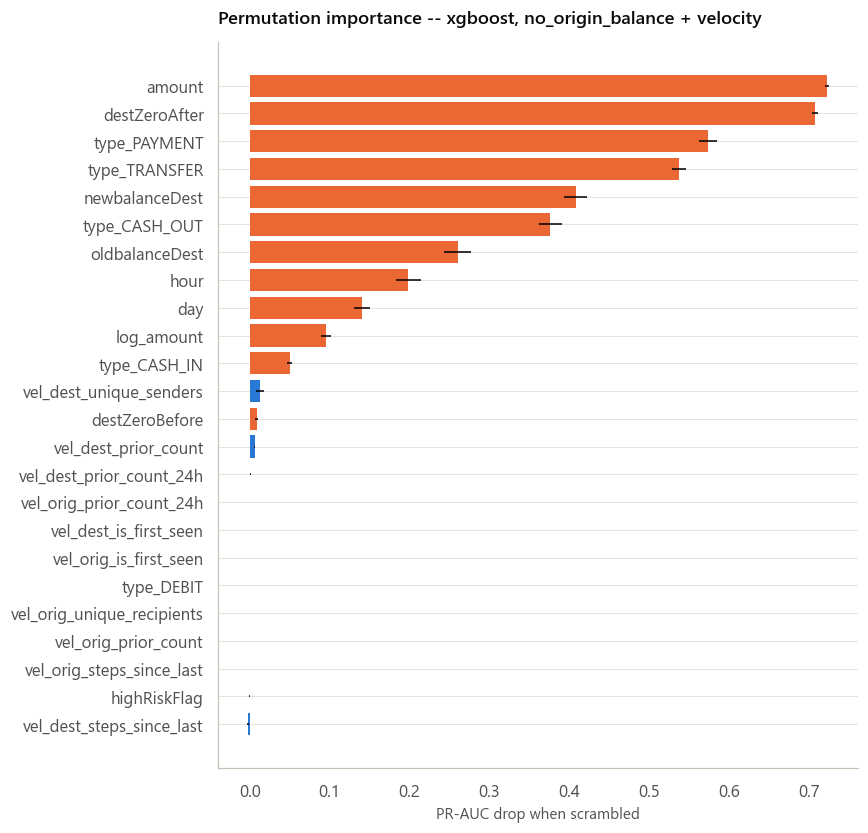

In [ ]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(perm_df))))
colors = [viz.CATEGORICAL[0] if v else viz.CATEGORICAL[1] for v in perm_df["is_velocity"]]
ax.barh(perm_df["feature"], perm_df["drop"], xerr=perm_df["std"],
       color=colors, error_kw={"linewidth": 1})
ax.invert_yaxis()
ax.set(title=f"Permutation importance {winning_learner}, {RUNG} + velocity",
      xlabel="PR-AUC drop when scrambled")
viz.despine(ax)
plt.tight_layout()
viz.save_figure(fig, "09_permutation_importance")
plt.show()

## Write-up

**The causal-invariance argument, restated for the report.** Velocity
features are computed once, on the full ordered transaction table, before
either split in this notebook is constructed. Every column is a function of
transactions strictly before the row's own `step` the same information a
live production system streaming transactions in real time would have.
Nothing about split membership (stratified or temporal) ever enters the
computation, which is why the comparison above is run under both splits
rather than just the primary one: if the features leaked through the split
boundary, the temporal split the harder, more honest test, where val/test
genuinely are the future relative to train would be where that leakage
showed up as a stratified-only win that evaporates. `tests/test_velocity.py`
makes this a property the test suite proves, not merely a claim in this
paragraph: row-order invariance, no-look-ahead under truncation, and
split-independence are all directly tested.

**Read the `vel_orig_is_first_seen` number above before treating a weak
origin-side result as a bug.** PaySim's customer (`C`-prefixed) origin
accounts are overwhelmingly one-shot the 63.28% account-reuse figure in
`02_account_overlap.json` is a `nameDest`-side statistic. A near-1.0
first-seen rate on the origin side is the data, not an error in this
notebook; `vel_dest_*` (especially `vel_dest_unique_senders`, the fan-in /
mule-account signal) is where any real signal should live, and the
permutation-importance table above is the direct check of whether it did.